## What is and isn't knowable

Four levels of detail, and a crucial distinction between *can't* and *won't*:

| Level of detail | Why **we** can obtain it | Could a vendor expose it? | Do vendors expose it today? |
|---|---|---|---|
| Per-call token counts | The API returns usage on every response; we record each call | **Yes, trivially** — they already have the number | **Rarely.** Most agent products report one total per request, not per internal step |
| Reasoning / cached tokens | Provider reports them in the usage payload | **Yes** — pure passthrough of a field they already receive | **Almost never**, despite both affecting the bill |
| Context composition | We assembled the prompt, so we know what went into it | **Partly** — they could publish *shares* without revealing prompt text | **No.** It would expose prompt engineering they treat as proprietary |
| Inside the model | — | **No — genuinely impossible.** Nobody can inspect the forward pass | n/a |

**Reading the last column:** "do vendors expose it" means *what a customer of a
commercial agent product can actually see about their own usage today* — through the
product UI, its API response, or its billing detail. It is a statement about disclosure
practice, not about capability.

**Only the last row is a technical limit.** Everything above it is a choice about what
to surface. That distinction is the whole argument: the gap is mostly *withheld*, not
*impossible*.

## Honest limits, stated up front

Even at the ceiling we are not omniscient. Every number in this notebook carries a
**tier**:

- **verified** — we can independently check the underlying content, because we assembled it
- **trusted** — the vendor reported it; we record it faithfully but cannot audit it
- **asserted** — reported but uninspectable (hidden reasoning: we get a size, never the text)

And a **residual** row is always shown. If our decomposition disagrees with the API's
reported total, that disagreement is printed rather than hidden.

> Full methodology: [`docs/transparency_spec.md`](docs/transparency_spec.md)

## 1. Setup

All implementation lives in `src/`. This notebook is the narrative.

| Module | Role |
|---|---|
| `support_dataset` / `support_tools` | Corpus + **real** tools under a sandbox contract |
| `support_agents` | Supervisor → Planner → Navigator → Validator, per-call instrumented |
| `otel` | `Usage` (incl. cached + reasoning tokens), `LLMCallRecorder` |
| `attribution` | The headline table and derived metrics |
| `reasoning` | Plan–execution divergence, reasoning provenance |

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import pandas as pd
from IPython.display import display
pd.set_option('display.width', 140)
pd.set_option('display.max_colwidth', 60)

from src import (
    Config, HierarchicalTracer, TracingManager,
    load_support_corpus, init_support_tools, workspace_manifest, TOOL_EFFECT_CLASS,
    create_support_mas, run_support_mas, evaluate_support_outcome,
    attribution, reasoning, interpret,
    plot_token_attribution, plot_stage_bars, plot_context_growth, plot_trace_tree,
    plot_hidden_reasoning, plot_tool_usage,
)

Config.setup_dirs()
print('imports OK')

imports OK


### How this multi-agent system is built

The MAS is assembled with **LangChain** and **LangGraph** — the same stack as the
Mind2Web notebook, so results are comparable:

| Specialist | Implemented as | Tools? | Why it exists |
|---|---|---|---|
| **Supervisor** | plain Python dict lookup — *no LLM call* | no | Deterministic routing. Costs zero tokens, by construction |
| **Planner** | LangChain chat model, single call | no | Decomposes the ticket into named tool steps |
| **Navigator** | LangGraph `create_react_agent` | **yes** | Runs the ReAct loop: think → call tool → observe → repeat |
| **Validator** | LangChain chat model, single call | no | Independently checks the draft against policy |

Only the Navigator is an *agent* in the LangGraph sense (a graph that loops). The others
are single model calls with a role prompt. Instrumentation is attached through
LangChain's **callback system**, so token capture works identically for both shapes and
would work for any LangChain-compatible provider.

### Model assignment

The **Planner runs a reasoning model on purpose.** Planning is where extended reasoning
is most defensible *and* most invisible — which makes it the exhibit.

Model names below are shortened for display (deployment ids and date stamps stripped);
nothing here assumes a specific vendor.

In [2]:
# Config.display_model() strips deployment ids/date stamps, provider-agnostically.
mas_models = {
    'supervisor': None,                        # no LLM — deterministic routing
    'planner':    Config.SUPPORT_PLANNER_MODEL,
    'navigator':  Config.SUPPORT_NAVIGATOR_MODEL,
    'validator':  Config.SUPPORT_VALIDATOR_MODEL,
}
for role, m in mas_models.items():
    if m is None:
        print(f'  {role:11} deterministic routing (0 tokens)')
        continue
    tag = '  ← reasoning model' if Config.is_reasoning_model(m) else ''
    print(f'  {role:11} {Config.display_model(m)}{tag}')

  supervisor  deterministic routing (0 tokens)
  planner     o4-mini  ← reasoning model
  navigator   gpt-5-4
  validator   gpt-4-1


### What "reasoning model" means here

A **reasoning model** generates an internal chain of thought *before* producing its
visible answer. Three consequences matter for this notebook:

1. **Those thinking tokens are billed as output tokens** at the normal output rate.
2. **They are never returned to the caller.** The API tells you *how many* there were
   (`reasoning_tokens`) but not what they said.
3. They usually reject `temperature` and require a larger token budget, since the budget
   must cover reasoning the caller never sees.

So a reasoning model is precisely a model that charges you for text you cannot read.
That is why one sits on the Planner: it makes the transparency gap measurable inside our
own system rather than as a claim about someone else's.

**How we detect it.** `Config.is_reasoning_model()` is a *name heuristic* only, and is
configurable via `REASONING_MODEL_PATTERNS` for non-OpenAI providers. The authoritative
signal is behavioural: if the API reports non-zero `reasoning_tokens`, the model is doing
hidden reasoning whatever it is called. **Attribution always uses the reported number,
never the name guess** — so a mislabelled model costs a label, not a measurement.

## 2. The support desk — real tools, contained effects

The Mind2Web notebook mocks every WRITE action, so consequences are unobservable and
only *trajectory* can be scored. Here the tools are real:

| Tool | Real action | Effect |
|---|---|---|
| `search_kb`, `read_policy`, `read_order`, `read_ticket` | real file reads | read / local |
| `web_search` | real Tavily (optional) | read / **external** |
| `draft_response` | **real file write** to `workspace/drafts/` | **write / local** |
| `escalate` | **real append** to `workspace/escalations.jsonl` | **write / local** |

The blast radius is contained by a contract enforced in code, not convention:
a path-traversal guard on every write, no network writes, a per-run allowlist, safety
validation on write-tool **inputs**, and a gitignored workspace reset each run.

### The corpus is a measuring instrument

It is synthetic on purpose — like a resolution chart for a camera lens. You don't shoot
a test chart because you can't find real scenes; you shoot it because its properties are
**known**, which is what makes the measurement falsifiable. Each planted trap validates
a specific metric, and because there is ground truth we can score **outcomes**, not just
trajectories.

In [3]:
corpus = load_support_corpus()
workspace = init_support_tools(corpus, reset=True)

s = corpus.summary()
print(f"KB articles {s['kb_articles']} · policies {s['policies']} · orders {s['orders']} · tickets {s['tickets']}")
print(f"difficulty: {s['difficulty']}")
print(f"planted traps: {s['traps']}")
print(f"sandbox workspace: {workspace}")

pd.DataFrame([{
    'id': t.id, 'difficulty': t.difficulty, 'trap': t.trap or '—',
    'subject': t.subject, 'expects': ', '.join(t.expected_articles),
    'escalate': t.should_escalate,
} for t in corpus.tickets])

KB articles 19 · policies 5 · orders 8 · tickets 15
difficulty: {'easy': 5, 'medium': 6, 'hard': 4}
planted traps: {'multi-hop': 3, 'duplicate-bait': 1, 'obvious-article-wrong': 2, 'escalation-required': 2}
sandbox workspace: /Users/minwu/Documents/GenAI/Agent/workspace


,id,difficulty,trap,subject,expects,escalate
0,T-1001,easy,—,How long do I have to send something back?,kb-returns-window,False
1,T-1002,easy,—,Where is my tablet?,kb-shipping-tracking,False
2,T-1003,easy,—,Can't sign in,kb-account-login,False
3,T-1004,easy,—,Keyboard is cheaper now,kb-price-match,False
4,T-1005,easy,—,Gift card plus discount code?,kb-gift-cards,False
5,T-1006,medium,multi-hop,Monitor arrived cracked - I'm in Canada,"kb-damaged-items, kb-international-orders, kb-refund-timing",False
6,T-1007,medium,duplicate-bait,"Charged twice, and when does my refund land?","kb-duplicate-charge, kb-refund-timing",False
7,T-1008,medium,obvious-article-wrong,Please cancel my order,"kb-order-cancellation, kb-returns-window",False
8,T-1009,medium,multi-hop,Dropped my camera - am I covered?,"kb-care-plan, kb-warranty",False
9,T-1010,medium,—,You sent the wrong display,"kb-wrong-item, kb-returns-shipping-label",False


## 3. Run the multi-agent system

Every LLM call is recorded individually. That matters: aggregate accounting collapses a
multi-turn navigator into one number, which makes re-planning, retries, and per-turn
context growth **unobservable by construction**.

Set `N_TICKETS` lower for a quick pass.

In [4]:
N_TICKETS = len(corpus.tickets)      # lower this for a faster/cheaper run

mas = create_support_mas(Config)
tracer, tm = HierarchicalTracer(), TracingManager()
print(f'tool definitions cost {mas["tool_schema_tokens"]} tokens — resent on EVERY navigator turn\n')

runs, outcomes = [], []
for t in corpus.tickets[:N_TICKETS]:
    r = run_support_mas(t, mas, tracer, tm, Config)
    o = evaluate_support_outcome(t, r.cited_articles, r.escalated)
    runs.append(r); outcomes.append(o)
    u = r.total_usage()
    flag = '✅' if o.passed else '❌'
    print(f'{flag} {t.id} [{t.difficulty:6}] {len(r.all_calls)} calls · {len(r.tool_calls)} tools · '
          f'{u.total_tokens:6,} tok (hidden {u.reasoning_tokens:4,}) · ${r.total_cost:.4f} · {r.latency_ms:,.0f}ms')

print(f'\nerrors: {sum(len(r.errors) for r in runs)}')
print('workspace:', workspace_manifest()['draft_count'], 'drafts,',
      workspace_manifest()['escalation_count'], 'escalations — real files on disk')

tool definitions cost 475 tokens — resent on EVERY navigator turn

✅ T-1001 [easy  ] 6 calls · 4 tools ·  7,158 tok (hidden  128) · $0.0208 · 13,928ms
❌ T-1002 [easy  ] 7 calls · 6 tools ·  9,304 tok (hidden  256) · $0.0266 · 14,375ms
✅ T-1003 [easy  ] 5 calls · 3 tools ·  4,953 tok (hidden  320) · $0.0160 · 13,887ms
✅ T-1004 [easy  ] 5 calls · 5 tools ·  5,679 tok (hidden  192) · $0.0168 · 11,362ms
✅ T-1005 [easy  ] 6 calls · 4 tools ·  6,937 tok (hidden  256) · $0.0200 · 13,676ms
✅ T-1006 [medium] 5 calls · 7 tools ·  7,781 tok (hidden  320) · $0.0245 · 14,068ms
✅ T-1007 [medium] 6 calls · 5 tools ·  8,128 tok (hidden  320) · $0.0257 · 16,809ms
❌ T-1008 [medium] 6 calls · 7 tools ·  8,516 tok (hidden  576) · $0.0250 · 15,261ms
✅ T-1009 [medium] 5 calls · 5 tools ·  6,475 tok (hidden  320) · $0.0201 · 15,935ms
❌ T-1010 [medium] 6 calls · 6 tools ·  7,797 tok (hidden  192) · $0.0231 · 13,148ms
✅ T-1011 [medium] 6 calls · 5 tools ·  7,316 tok (hidden  128) · $0.0226 · 16,208ms
❌ T-1012 

## 4. ⭐ Where the tokens went

**The headline artifact.** One invariant governs this table:

> **Total = Σ over LLM calls of (input + output).** Every row is a *decomposition* of
> that total, never an addition to it.

That rule matters. Tool outputs are tempting to list as their own line, but they are
already *inside* the next call's input tokens — counting them separately would inflate
the denominator and make every share wrong. So input decomposes into context categories
plus a residual; output decomposes into visible text and hidden reasoning.

### How to read **Method** and **Tier**

These answer two different questions, which is why a row can be `estimated` *and*
`verified` at the same time — a combination that looks contradictory until you separate
them:

| Column | Question it answers | Values |
|---|---|---|
| **Method** | *How was this number produced?* | `api` — the provider reported it · `estimated` — we counted it with a tokenizer · `residual` — arithmetic remainder |
| **Tier** | *How far can this number be trusted?* | `verified` — we hold the underlying content and can recount it · `trusted` — vendor-reported, unauditable · `asserted` — reported, uninspectable |

**Worked example — "System prompts: estimated / verified".** We wrote the system prompt,
so we possess the exact text and can re-count it any time, on any tokenizer: the
*content* is verified. But the provider never tells us how many tokens that specific
segment consumed — it only reports one total for the whole request — so our number is a
tokenizer *estimate*. Verified content, estimated count.

Conversely **"Visible response: api / trusted"**: the count comes straight from the
provider (`api`), but we cannot audit their tokenizer, so it is `trusted` rather than
`verified`. And **hidden reasoning is `asserted`** — we have neither the text nor any way
to check the count.

**This is why the residual exists.** It is where the estimated decomposition meets the
trusted total, and any disagreement between them becomes visible instead of being
silently absorbed.

In [5]:
attribution.attribution_dataframe(tracer)

,Dimension,Category,Tokens,Share,Calls,Method,Tier
0,INPUT,System prompts,11121,9.7%,—,estimated,verified
1,INPUT,Tool definitions,27075,23.7%,—,estimated,verified
2,INPUT,Task / ticket,20646,18.0%,—,estimated,verified
3,INPUT,Retrieved knowledge (tool output),31041,27.1%,82,estimated,verified
4,INPUT,Conversation history,7753,6.8%,—,estimated,verified
5,INPUT,Unaccounted (residual),2428,2.1%,—,residual,—
6,OUTPUT,Visible response,9662,8.4%,87,api,trusted
7,OUTPUT,Hidden reasoning,4736,4.1%,—,api,asserted
8,TOTAL,All tokens,114462,100.0%,87,api,trusted


In [6]:
att = attribution.token_attribution(tracer)
print(f"total {att['total_tokens']:,} tokens across {att['llm_calls']} LLM calls")
print(f"input {att['input_tokens']:,} · output {att['output_tokens']:,}")
print(f"hidden reasoning {att['reasoning_tokens']:,} ({att['hidden_share']:.0%} of output)")
print(f"cached input {att['cached_tokens']:,}")
print(f"\nresidual {att['residual_tokens']:+,} ({att['residual_share']:.1%} of input)")
print('  Positive = we under-account; negative = we over-account.')
print('  Expected residual sources: per-message framing charged by the provider but')
print('  present in no message body, and tokenizer differences on our estimated rows.')
print('  It is reported rather than tuned away — that is the honesty mechanism.')

total 114,462 tokens across 87 LLM calls
input 100,064 · output 14,398
hidden reasoning 4,736 (33% of output)
cached input 1,664

residual +2,428 (2.4% of input)
  Positive = we under-account; negative = we over-account.
  Expected residual sources: per-message framing charged by the provider but
  present in no message body, and tokenizer differences on our estimated rows.
  It is reported rather than tuned away — that is the honesty mechanism.


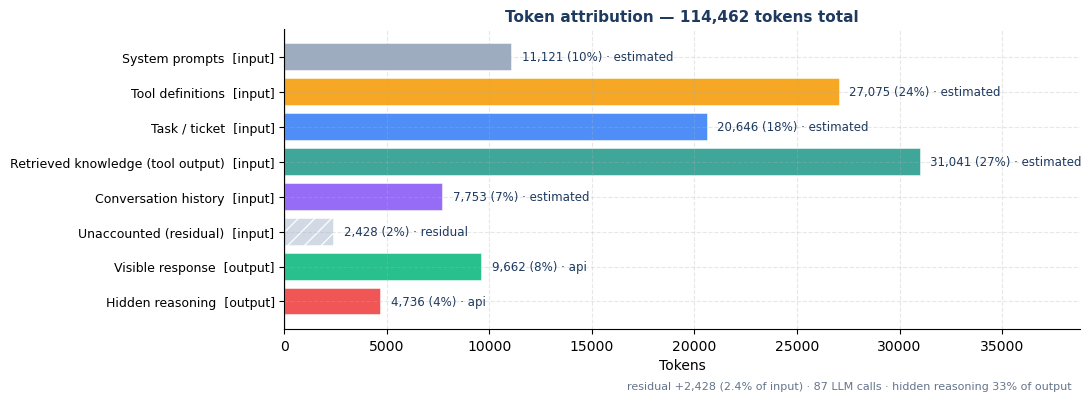

In [7]:
fig = plot_token_attribution(tracer, save_path=Config.OUTPUT_DIR / 'token_attribution.png')

In [8]:
# Rule-based reading of the table above. Pass judge_llm=... to add an AI narrative.
interpret.interpret_attribution(tracer).show()

Token attribution
-----------------
114,462 tokens across 87 LLM calls; residual 2.4%.

  • Largest single category is retrieved knowledge (tool output) at 27% of all tokens (31,041).
  • Spend is input-dominated: 87% input vs 13% output. Since output is typically priced several times higher per token, the cost split is less lopsided than the token split.
  • Residual is 2.4% of input: the decomposition closely matches the reported total.  [+2,428 tokens]
  • The residual is positive, i.e. we under-account. Per-message framing overhead is charged by the provider but not represented in any message body, so a small positive residual is the expected resting state.
  • 1,664 input tokens were served from cache and billed at a different rate. Token counts are reproducible; the resulting cost is not.


### The same total, cut by workflow stage

An orthogonal view. Both cuts sum to 100% of the measured total; neither is added to the
other. Note the Supervisor row: **zero tokens, by construction.**

In [9]:
stages = attribution.stage_breakdown(tracer)
pd.DataFrame([{
    'Stage': s['stage'], 'Tokens': f"{s['tokens']:,}", 'Share': f"{s['share']:.1%}",
    'LLM calls': s['calls'], 'Hidden reasoning': s['hidden_reasoning'],
    'Method': s['method'], 'Tier': s['tier'],
} for s in stages])

,Stage,Tokens,Share,LLM calls,Hidden reasoning,Method,Tier
0,Routing / orchestration,0,0.0%,0,0,verified,verified
1,Planning,"9,438",8.2%,15,4736,api,trusted
2,Navigation & response,"91,730",80.1%,57,0,api,trusted
3,Verification,"13,294",11.6%,15,0,api,trusted


## 5. Exhibits

Five findings that standard token accounting cannot surface.

### 5a. The tool-definition tax

Tool schemas are sent with **every single turn**, whether or not the agent calls those
tools. This is invisible in any per-request total, and it is directly actionable: trim
the tool set for a task class and the saving is immediate.

In [10]:
ts = attribution.tool_schema_overhead(tracer)
print(f"tool definitions: {ts['tokens_per_turn']:,} tokens, resent on each of {ts['turns_charged']} turns")
print(f"total: {ts['total_tokens']:,} tokens = {ts['share_of_input']:.0%} of ALL input")
print(f"distinct tools actually used across the run: {ts['distinct_tools_used']} of {len(mas['tools'])}")
print(f"\nfor comparison, the navigator system prompt is a few dozen tokens.")

tool definitions: 475 tokens, resent on each of 57 turns
total: 27,075 tokens = 27% of ALL input
distinct tools actually used across the run: 6 of 7

for comparison, the navigator system prompt is a few dozen tokens.


### 5b. Context growth — you pay for the same words repeatedly

Every ReAct turn resends the full conversation. New information arrives linearly;
re-sent context accumulates. In long runs this dominates everything else.

navigator input: 784 → 2,148 tokens (2.7x)
re-sent context (history + prior tool output): 45% of all navigator input


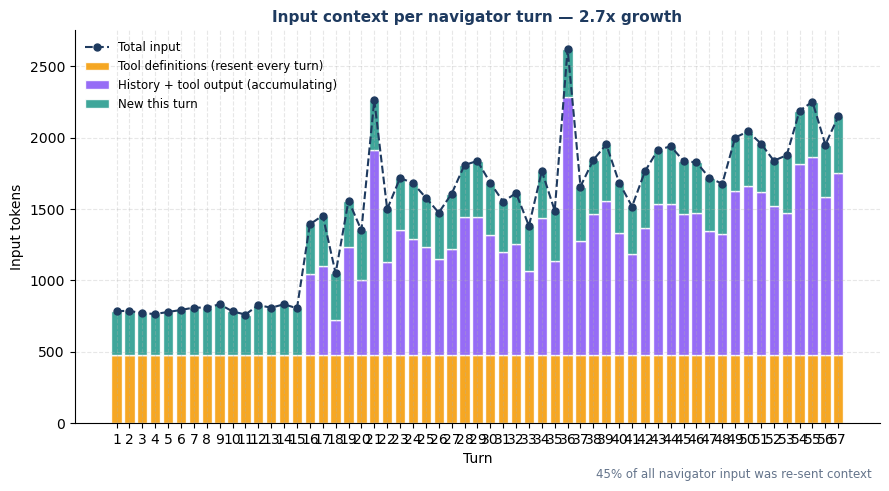

In [11]:
g = attribution.context_growth(tracer)
print(f"navigator input: {g['first_input_tokens']:,} → {g['last_input_tokens']:,} tokens "
      f"({g['growth_factor']:.1f}x)")
print(f"re-sent context (history + prior tool output): {g['resent_share']:.0%} of all navigator input")
fig = plot_context_growth(tracer, save_path=Config.OUTPUT_DIR / 'context_growth.png')

In [12]:
interp = interpret.interpret_context_growth(tracer)
interp.show()

# Optional AI narrative (advisory; rule-based findings above are the record):
# interpret.interpret_context_growth(tracer, judge_llm=Config.create_llm(role='judge')).show()

Context growth per navigator turn
---------------------------------
2.7x input growth over 57 turns; 45% of input was re-sent, 27% was tool definitions.

  ! Tool definitions consumed 27% of all input — 475 tokens re-declared every turn, of which only 6 tool(s) were actually used. Trimming the tool set for this task class is the single clearest saving available.  [27,075 tokens total]
  ▲ Input context grew 2.7x across 57 turns.  [784 → 2,148 tokens]
  ▲ 45% of navigator input was re-sent context.
  • Growth is superlinear in turn count: every turn resends all prior turns, so cost rises faster than the work performed. Capping turns or summarising history bounds it.


**How to read this chart.** Each bar is one navigator turn. The three bands separate
what you are paying for:

- 🟠 **Tool definitions** — identical every turn. A flat band means a fixed toll per turn,
  charged whether or not those tools get used.
- 🟣 **History + prior tool output** — *accumulating*. This band growing left-to-right is
  the agent re-reading its own past at full price.
- 🟢 **New this turn** — the only band representing genuinely new information.

A healthy run has the green band as a meaningful share. When purple and orange dominate
and the dashed total line climbs steeply, you are paying progressively more per unit of
new work.

The reading below is **rule-based** — explicit thresholds on measured values, printed
alongside the numbers that triggered them — so it is reproducible and checkable. Supply
`judge_llm=` to add an AI narrative on top; it receives the *numbers*, never the image,
and is always labelled.

### 5c. Hidden reasoning — billed, but unreadable

The sharpest exhibit. Reasoning models generate a chain of thought, **charge you for
it**, and never return it. The size is reported; the content is withheld. This is a
disclosure choice, not a technical limit.

In [13]:
h = attribution.hidden_reasoning(tracer)
print(f"hidden reasoning: {h['hidden_tokens']:,} of {h['output_tokens']:,} output tokens "
      f"({h['hidden_share']:.0%})\n")
for agent, d in h['by_agent'].items():
    if d['output']:
        print(f"  {agent:11} {d['reasoning']:5,} / {d['output']:5,} output = {d['hidden_share']:.0%} unreadable")
print('\nYou paid for every one of those tokens. You cannot read any of them.')

hidden reasoning: 4,736 of 14,398 output tokens (33%)

  planner     4,736 / 6,657 output = 71% unreadable
  navigator       0 / 5,852 output = 0% unreadable
  validator       0 / 1,889 output = 0% unreadable

You paid for every one of those tokens. You cannot read any of them.


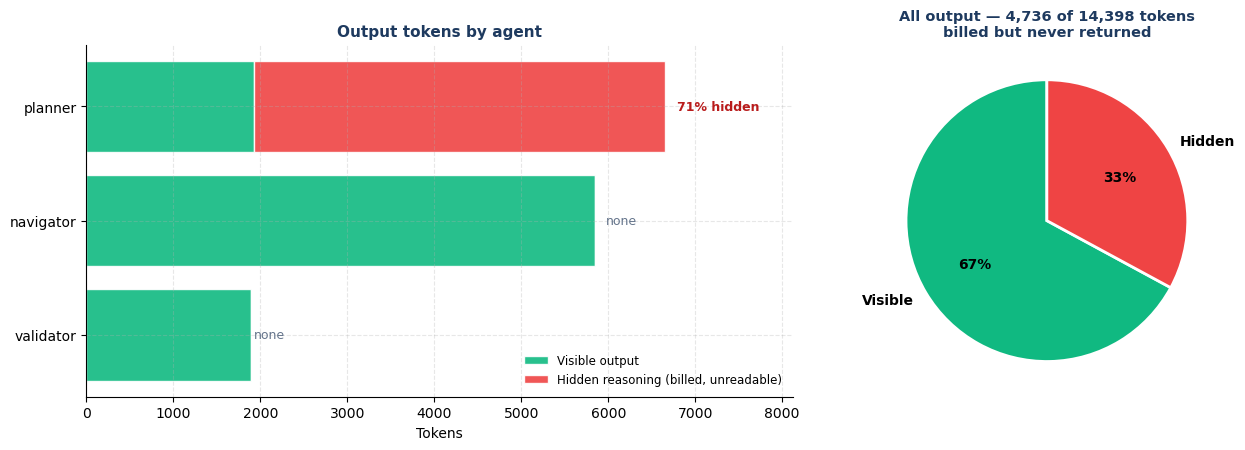

In [14]:
fig = plot_hidden_reasoning(tracer, save_path=Config.OUTPUT_DIR / 'hidden_reasoning.png')

**How to read this chart.** Left: output tokens per agent, split into 🟢 visible text and
🔴 reasoning that was billed but never returned. Right: the same split across the whole
run.

Agents on non-reasoning models show no red at all — that contrast is the point. The
hidden slice is a property of *which model you chose*, not of how hard the task was. An
agent showing 60% red delivered less than half of what you paid for on the output side,
in readable form.

In [15]:
interpret.interpret_hidden_reasoning(tracer).show()

Hidden reasoning — billed but unreadable
----------------------------------------
4,736 of 14,398 output tokens (33%) were never returned to the caller.

  ▲ 33% of output tokens were hidden reasoning.  [4,736 tokens]
  • planner: 71% of its output was unreadable (4,736 of 6,657 tokens).
  • This is a disclosure choice, not a technical limit: the provider generated this text and charged for it. Auditing whether that reasoning was sound is impossible from outside — only its size is knowable.


### 5d. Cost is not reproducible, even when tokens are

Token counts are deterministic — the same messages always tokenize identically. **Cost
is not.** Cache hits depend on TTL and eviction you do not control, so the same request
billed twice can differ. Attribution *by token* is reproducible; attribution *by dollar*
is an estimate, and this notebook labels it as one.

The cell below demonstrates it directly: one identical prompt, sent twice.

In [16]:
from langchain_core.messages import HumanMessage
probe_llm = Config.create_llm(role='agent', model=Config.SUPPORT_NAVIGATOR_MODEL)
big = 'Knowledge base article. ' + ('Policy detail sentence for refunds and returns. ' * 260)

for n in (1, 2):
    r = probe_llm.invoke([HumanMessage(content=big + '\n\nReply with the single word OK.')])
    um = r.usage_metadata
    cached = (um.get('input_token_details') or {}).get('cache_read', 0)
    print(f"call {n}: input={um['input_tokens']:,} cached={cached:,} "
          f"({cached/max(um['input_tokens'],1):.0%} served from cache)")
print('\nIdentical tokens. Different cost. Determined by state we do not control.')

call 1: input=2,098 cached=0 (0% served from cache)
call 2: input=2,098 cached=0 (0% served from cache)

Identical tokens. Different cost. Determined by state we do not control.


### 5e. Duplicate retrievals

Argument fingerprints make repeated identical retrievals visible — did the agent pay
twice for the same information? Costs nothing to detect.

In [17]:
d = attribution.duplicate_retrievals(tracer)
print(f"tool calls {d['total_calls']} · unique {d['unique_calls']} · duplicates {d['duplicate_calls']}")
print(f"estimated wasted tokens: {d['wasted_tokens_est']:,}")
if d['detail']:
    display(pd.DataFrame(d['detail']))
else:
    print('\nNo duplicates in this run. The metric reports zero honestly — the corpus')
    print('contains bait for duplication, but bait is an opportunity, not a guarantee.')

rp = attribution.replanning_count(tracer)
print(f"\nre-plans: {rp['replans']} · navigator turns: {rp['navigator_turns']} · "
      f"tool calls: {rp['tool_calls']} ({rp['tools_per_turn']:.1f} per turn)")
print('Turns ≠ tool calls: models emit several tool calls per turn (parallel calling).')

tool calls 82 · unique 64 · duplicates 18
estimated wasted tokens: 2,129


,tool,fingerprint,occurrence
0,read_policy,ef005c1c1b46,2
1,read_policy,ef005c1c1b46,3
2,read_policy,ef005c1c1b46,4
3,read_order,57accb4c275d,2
4,read_policy,245c6652b7b2,2
5,read_policy,5be70423b2e3,2
6,read_policy,ef005c1c1b46,5
7,read_policy,5be70423b2e3,3
8,read_policy,ef005c1c1b46,6
9,read_policy,5be70423b2e3,4



re-plans: 14 · navigator turns: 57 · tool calls: 82 (1.4 per turn)
Turns ≠ tool calls: models emit several tool calls per turn (parallel calling).


**How to read the chart below.** One bar per tool, length = tokens its outputs added to
context. Hatched red = duplicate calls, i.e. tokens paid twice for information the agent
already had. The `(Nx)` in each label is the call count.

Long bars identify which tool is really driving context size — usually a retrieval tool
returning more than the agent needs.

Tool usage and duplicate retrievals
-----------------------------------
82 tool calls, 64 unique; retrieved content was 31% of all input.

  ! 18 of 82 tool calls repeated an identical request, costing about 2,129 tokens to re-obtain information the agent already had. Caching results within a run removes this.  [22% of calls]
  • Retrieved content was 31% of input.


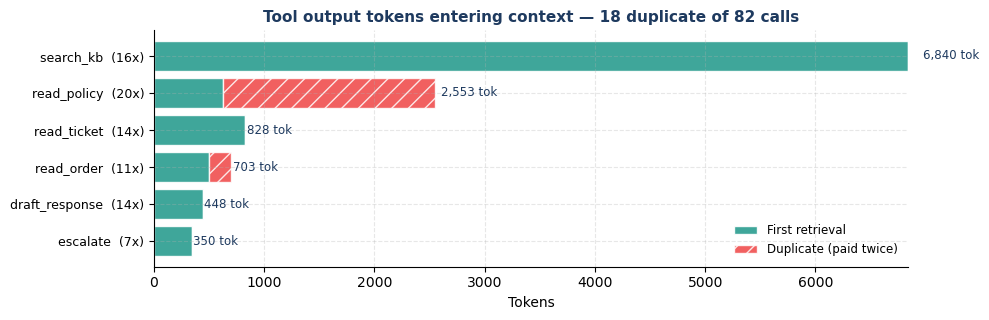

In [18]:
fig = plot_tool_usage(tracer, save_path=Config.OUTPUT_DIR / 'tool_usage.png')
interpret.interpret_tool_usage(tracer).show()

## 6. Reasoning transparency

### Architecture is a transparency choice

A single reasoning-model call hides its planning inside the opaque layer. Decomposing
into Planner → Navigator → Validator moves that same reasoning into **inspectable
inter-agent messages**. The multi-agent system costs more *and* makes reasoning
auditable — a dimension the usual quality/cost comparison misses entirely.

### But a reasoning narrative is a *claim about* process, not process

Chain-of-thought is frequently unfaithful: models reach answers via factors they don't
mention, then rationalize. Fluent reasoning is strong evidence of a well-trained writer,
not of a sound process.

So we evaluate reasoning by its **consequences and its consistency with the trace**, not
by reading it.

In [19]:
inv = reasoning.reasoning_inventory(tracer)
pd.DataFrame(inv.as_rows())

,layer,tokens,provenance,auditable,note
0,"Externalized (plans, rationales)",183.0,externalized,yes,Verified — the full text was produced as output and capt...
1,Hidden reasoning tokens,4736.0,hidden,no (billed),"Unavailable — generated and billed, but never returned t..."
2,Latent computation,NaN,n/a,impossible,"Not observable by any API consumer, including the vendor's."


### Plan–execution divergence — the deterministic faithfulness check

We have the Planner's *stated* steps and the Navigator's *actual* tool calls. Comparing
them needs no judge: the plan is a testable claim and the trace is ground truth about
what happened.

This is uniquely enabled by the multi-agent architecture. A single agent that plans
internally leaves nothing to compare against.

In [20]:
div_rows = []
for r in runs:
    d = reasoning.plan_execution_divergence(r.plan, source={r.trace_id: tracer.traces.get(r.trace_id, [])})
    div_rows.append({
        'ticket': r.ticket_id, 'planned': len(d.planned), 'executed': len(set(d.executed)),
        'followed': len(d.followed), 'skipped': ', '.join(d.skipped) or '—',
        'unplanned': ', '.join(d.unplanned) or '—',
        'fidelity': f'{d.fidelity:.0%}', 'verdict': d.verdict,
    })
pd.DataFrame(div_rows)

,ticket,planned,executed,followed,skipped,unplanned,fidelity,verdict
0,T-1001,4,4,4,—,—,100%,faithful — executed exactly the planned tools
1,T-1002,5,6,5,—,read_policy,100%,mostly faithful — minor deviation
2,T-1003,4,3,3,escalate,—,75%,mostly faithful — minor deviation
3,T-1004,4,5,4,—,search_kb,100%,mostly faithful — minor deviation
4,T-1005,4,4,4,—,—,100%,faithful — executed exactly the planned tools
5,T-1006,5,5,5,—,—,100%,faithful — executed exactly the planned tools
6,T-1007,5,5,4,escalate,read_policy,80%,mostly faithful — minor deviation
7,T-1008,5,6,5,—,search_kb,100%,mostly faithful — minor deviation
8,T-1009,5,5,5,—,—,100%,faithful — executed exactly the planned tools
9,T-1010,4,6,4,—,"search_kb, escalate",100%,mostly faithful — minor deviation


### Did the reasoning buy anything?

Correlational, not causal — but a flat or negative relationship is strong evidence that
reasoning spend is decorative. Establishing causality needs ablation (remove the plan,
rerun), which is deliberately out of scope here because it costs a full re-run per
condition.

In [21]:
records = []
for r, o in zip(runs, outcomes):
    t = next(x for x in corpus.tickets if x.id == r.ticket_id)
    u = r.total_usage()
    records.append({'difficulty': t.difficulty, 'reasoning_tokens': u.reasoning_tokens,
                    'total_tokens': u.total_tokens, 'passed': o.passed})

rc = attribution.reasoning_vs_complexity(records)
print('reasoning spend by task difficulty:')
for diff, v in rc['by_difficulty'].items():
    pr = f"{v['pass_rate']:.0%}" if v['pass_rate'] is not None else 'n/a'
    print(f"  {diff:7} n={v['n']:2}  avg reasoning {v['avg_reasoning_tokens']:7,.0f} tok  "
          f"avg total {v['avg_total_tokens']:7,.0f}  pass {pr}")
print(f"\ncorrelation(difficulty, reasoning): {rc['difficulty_reasoning_correlation']}")
print(f"→ {rc['interpretation']}")

oc = reasoning.reasoning_outcome_correlation(records)
print(f"\ncorrelation(reasoning spend, outcome): {oc['correlation']} (n={oc['n']})")
print(f"→ {oc['interpretation']}")

reasoning spend by task difficulty:
  easy    n= 5  avg reasoning     230 tok  avg total   6,806  pass 80%
  medium  n= 6  avg reasoning     309 tok  avg total   7,669  pass 67%
  hard    n= 4  avg reasoning     432 tok  avg total   8,604  pass 50%

correlation(difficulty, reasoning): 0.3478333929226201
→ reasoning is roughly flat across difficulty — possibly decorative

correlation(reasoning spend, outcome): -0.133 (n=15)
→ more reasoning tracks WORSE outcomes — likely struggling, not thinking


## 7. Outcome evaluation — beyond trajectory

Because the corpus has ground truth, we can score what actually happened, not just
whether the steps looked sensible.

The distinction matters. An agent that cites the correct article **and** the distractor
article, then escalates when policy says not to, has a perfectly plausible trajectory
— and a wrong outcome. Hedging by citing everything is not a pass.

In [22]:
pd.DataFrame([{
    'ticket': o.ticket_id, 'difficulty': o.difficulty, 'trap': o.trap or '—',
    'passed': '✅' if o.passed else '❌',
    'cited_correct': o.cited_correct, 'fell_for_trap': o.fell_for_trap,
    'escalation_ok': o.escalation_correct,
    'recall': f'{o.recall:.0%}', 'notes': '; '.join(o.notes) or '—',
} for o in outcomes])

,ticket,difficulty,trap,passed,cited_correct,fell_for_trap,escalation_ok,recall,notes
0,T-1001,easy,—,✅,True,False,True,100%,—
1,T-1002,easy,—,❌,True,False,False,100%,escalated when it should not have
2,T-1003,easy,—,✅,True,False,True,100%,—
3,T-1004,easy,—,✅,True,False,True,100%,—
4,T-1005,easy,—,✅,True,False,True,100%,—
5,T-1006,medium,multi-hop,✅,True,False,True,100%,—
6,T-1007,medium,duplicate-bait,✅,True,False,True,100%,—
7,T-1008,medium,obvious-article-wrong,❌,True,False,False,50%,escalated when it should not have; partial: missed ['kb-...
8,T-1009,medium,multi-hop,✅,True,False,True,50%,partial: missed ['kb-warranty']
9,T-1010,medium,—,❌,True,False,False,50%,escalated when it should not have; partial: missed ['kb-...


In [23]:
n = len(outcomes)
print(f"pass rate           {sum(o.passed for o in outcomes)}/{n} = {sum(o.passed for o in outcomes)/n:.0%}")
print(f"cited correctly     {sum(o.cited_correct for o in outcomes)}/{n}")
print(f"fell for a trap     {sum(o.fell_for_trap for o in outcomes)}/{n}")
print(f"escalation correct  {sum(o.escalation_correct for o in outcomes)}/{n}")
by = {}
for o in outcomes:
    by.setdefault(o.difficulty, []).append(o.passed)
print('\nby difficulty: ' + ' · '.join(f'{k} {sum(v)}/{len(v)}' for k, v in by.items()))

pass rate           10/15 = 67%
cited correctly     14/15
fell for a trap     1/15
escalation correct  10/15

by difficulty: easy 4/5 · medium 4/6 · hard 2/4


## 8. Per-ticket view

**How to read the chart below.** One stacked bar per ticket, coloured by workflow stage.
Two things to look for:

- **Bar height** = total tokens for that ticket. Wide variation means per-ticket
  budgeting matters more than an average — capacity planning on the mean will
  under-provision the expensive tail.
- **Colour mix** = where effort went. A tall 🟢 navigation band means execution dominated;
  a thick 🟠 verification band means checking cost nearly as much as doing.

Tickets that are structurally similar but differ sharply in height are worth opening
individually — that usually indicates extra ReAct turns, i.e. the agent struggled.

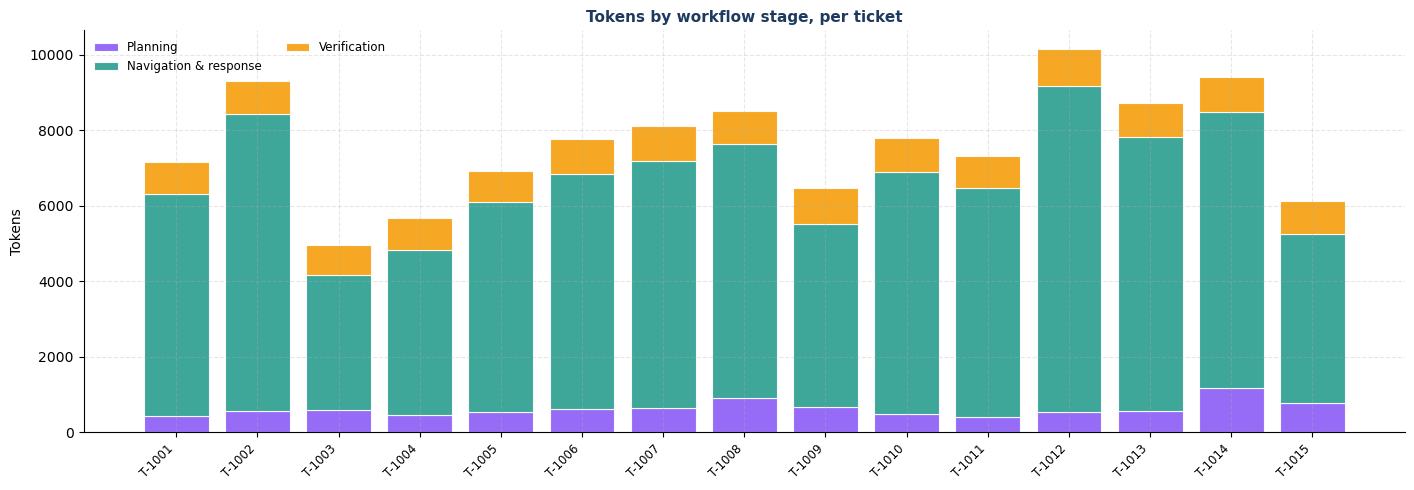

In [24]:
per_task = []
for r in runs:
    sub = {r.trace_id: tracer.traces.get(r.trace_id, [])}
    per_task.append({'label': r.ticket_id,
                     'stages': {s['stage']: s['tokens'] for s in attribution.stage_breakdown(sub)}})
fig = plot_stage_bars(per_task, save_path=Config.OUTPUT_DIR / 'stage_bars.png')

In [25]:
interpret.interpret_stage_bars(tracer, per_task=per_task).show()

Tokens by workflow stage
------------------------
Navigation 80% of spend; planning + verification overhead 20%.

  • Planning and verification overhead was 20% of spend (verification alone 12%).
  • Orchestration cost zero tokens: routing is deterministic code, not an LLM call. An LLM-routed supervisor would add cost on every task.
  • Per-ticket cost varied 2.0x (T-1003 4,953 → T-1012 10,142 tokens). Cost is fairly predictable.


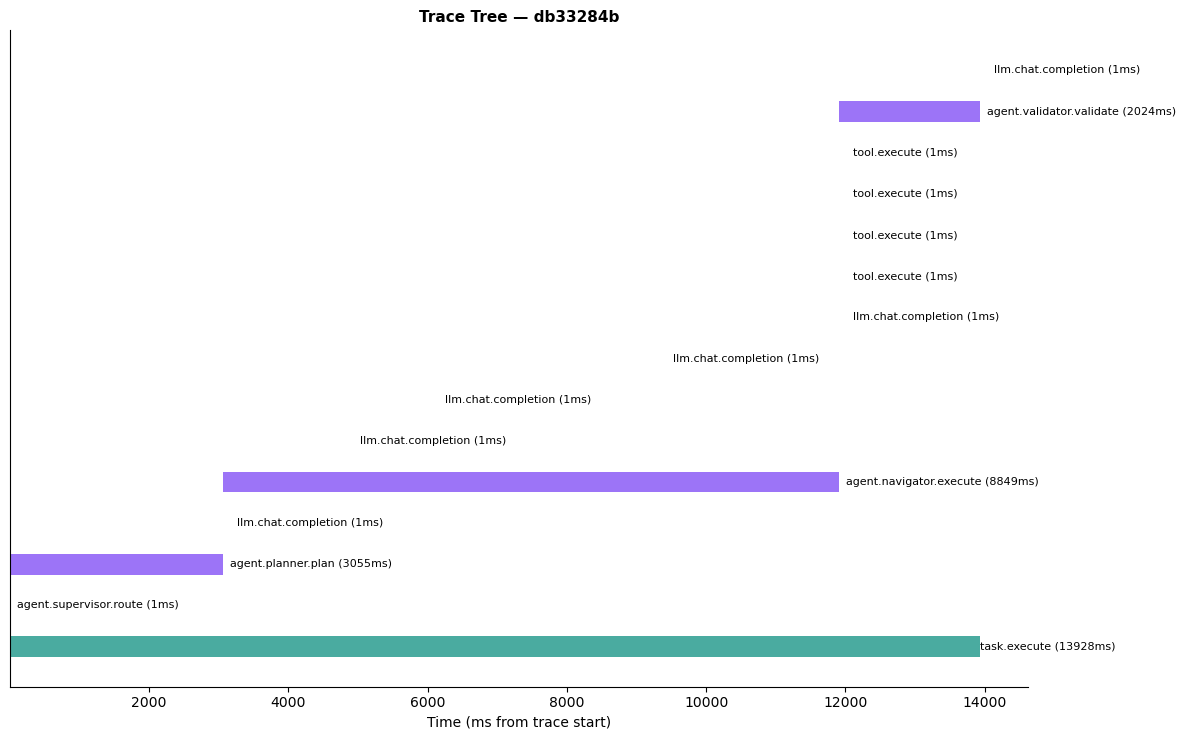

In [26]:
# Span tree for one ticket — structure, to sit alongside the mass view above
fig = plot_trace_tree(tracer, runs[0].trace_id, save_path=Config.OUTPUT_DIR / 'support_trace_tree.png')

## 8b. What OpenTelemetry and Phoenix add

This notebook uses the framework's **local tracer** so the analysis is reproducible with
no extra services. Every span it produces is also exportable as OTLP JSON, so the same
run can be viewed in a real observability backend — Phoenix, Datadog, Jaeger, Langfuse
(see [`docs/observability.md`](docs/observability.md)).

**What a backend adds, and what it does not:**

| Capability | Phoenix / OTel backend | This notebook |
|---|---|---|
| Per-call token counts and latency | ✅ automatic, live | ✅ |
| Search, filter, sort across thousands of runs | ✅ its core strength | ❌ |
| Cost roll-ups over time; run-to-run comparison | ✅ | partial |
| Drill into any single call's prompt and completion | ✅ | ✅ via spans |
| **Composition *inside* an input — how much was history vs tool schemas vs retrieval** | ❌ | ✅ |
| **Residual reconciliation against the reported total** | ❌ | ✅ |
| **Hidden-reasoning share surfaced as a first-class metric** | partial | ✅ |
| **Plan-vs-execution faithfulness** | ❌ | ✅ |

The distinction is the useful part: **a backend tells you a call used 4,312 input tokens.
It does not tell you that 1,900 of them were tool definitions the agent never used.**
That decomposition requires knowing how the prompt was assembled, which only the
orchestrator knows — so it has to be emitted at instrumentation time, not recovered later.

Run them together: Phoenix for live exploration and cross-run history, this analysis for
composition and provenance. Enable the live export with `setup_phoenix()`.

In [27]:
# Optional: stream these spans to a live backend as well.
# from src import setup_phoenix; setup_phoenix()   # → http://localhost:6006

stats = {'traces': len(tracer.traces),
         'spans': sum(len(v) for v in tracer.traces.values())}
print(f"local tracer: {stats['traces']} traces, {stats['spans']} spans "
      f"({stats['spans']/max(stats['traces'],1):.0f} per ticket)")
print('exportable as OTLP JSON → any OpenTelemetry backend')

local tracer: 15 traces, 244 spans (16 per ticket)
exportable as OTLP JSON → any OpenTelemetry backend


## 9. The transparency gap

Everything above is **the achievable ceiling when you control the stack**. Toggling
components, decomposing context, and instrumenting every call are possible only from
inside. None of it recovers hidden computation in someone else's product.

That boundary is the result, not a caveat. The distance between this ceiling and what a
commercial agent actually discloses **is** the transparency gap.

In [28]:
ladder = pd.DataFrame([
    {'Disclosure level': 'Total tokens per request',      'We demonstrated': '✅',
     'Vendor could disclose': '✅ trivially', 'Typically disclosed': 'usually'},
    {'Disclosure level': 'Per-call / per-turn tokens',    'We demonstrated': '✅',
     'Vendor could disclose': '✅ trivially', 'Typically disclosed': 'rarely'},
    {'Disclosure level': 'Cached vs fresh input',         'We demonstrated': '✅',
     'Vendor could disclose': '✅ passthrough', 'Typically disclosed': 'almost never'},
    {'Disclosure level': 'Reasoning token count',         'We demonstrated': '✅',
     'Vendor could disclose': '✅ passthrough', 'Typically disclosed': 'almost never'},
    {'Disclosure level': 'Context composition (shares)',  'We demonstrated': '✅',
     'Vendor could disclose': '✅ in aggregate', 'Typically disclosed': 'no'},
    {'Disclosure level': 'Reasoning token content',       'We demonstrated': '❌',
     'Vendor could disclose': '⚠️ they hold it', 'Typically disclosed': 'no'},
    {'Disclosure level': 'Latent computation',            'We demonstrated': '❌',
     'Vendor could disclose': '❌ impossible', 'Typically disclosed': 'n/a'},
])
ladder

,Disclosure level,We demonstrated,Vendor could disclose,Typically disclosed
0,Total tokens per request,✅,✅ trivially,usually
1,Per-call / per-turn tokens,✅,✅ trivially,rarely
2,Cached vs fresh input,✅,✅ passthrough,almost never
3,Reasoning token count,✅,✅ passthrough,almost never
4,Context composition (shares),✅,✅ in aggregate,no
5,Reasoning token content,❌,⚠️ they hold it,no
6,Latent computation,❌,❌ impossible,n/a


**Only the last row is a technical limit.** Everything above it is a choice.

And even our ceiling is not omniscience: we **verify** the context we built, **trust**
the vendor's usage counts, and can only **assert** the size of reasoning we cannot see.
The residual row is where verified and trusted meet — and where disagreement between
them becomes visible.

## 10. Save results

In [29]:
from datetime import datetime
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

df_runs = pd.DataFrame([{
    'ticket': r.ticket_id,
    'difficulty': next(x for x in corpus.tickets if x.id == r.ticket_id).difficulty,
    'llm_calls': len(r.all_calls), 'tool_calls': len(r.tool_calls),
    'input_tokens': r.total_usage().input_tokens,
    'output_tokens': r.total_usage().output_tokens,
    'reasoning_tokens': r.total_usage().reasoning_tokens,
    'cached_tokens': r.total_usage().cached_tokens,
    'cost_usd': round(r.total_cost, 6), 'latency_ms': round(r.latency_ms),
    'cited': ', '.join(r.cited_articles), 'escalated': r.escalated,
    'passed': next(o.passed for o in outcomes if o.ticket_id == r.ticket_id),
} for r in runs])
df_runs.to_csv(Config.OUTPUT_DIR / f'support_runs_{ts}.csv', index=False)

attribution.attribution_dataframe(tracer).to_csv(
    Config.OUTPUT_DIR / f'token_attribution_{ts}.csv', index=False)
path = tracer.save_all_traces(Config.TRACE_DIR, timestamp=f'support_{ts}')

print(f'saved → {Config.OUTPUT_DIR}')
print(f'OTLP traces → {path}')
print(f'\ntotal spend for this run: ${df_runs.cost_usd.sum():.4f} '
      f'({df_runs.input_tokens.sum() + df_runs.output_tokens.sum():,} tokens)')
df_runs

saved → outputs
OTLP traces → outputs/traces/all_otel_traces_support_20260814_014152.jsonl

total spend for this run: $0.3435 (114,462 tokens)


,ticket,difficulty,llm_calls,tool_calls,input_tokens,output_tokens,reasoning_tokens,cached_tokens,cost_usd,latency_ms,cited,escalated,passed
0,T-1001,easy,6,4,6465,693,128,0,0.020846,13928,"kb-returns-window, kb-returns-shipping-label",False,True
1,T-1002,easy,7,6,8455,849,256,0,0.026599,14375,kb-shipping-tracking,True,False
2,T-1003,easy,5,3,4042,911,320,0,0.015953,13887,kb-account-login,False,True
3,T-1004,easy,5,5,4995,684,192,0,0.016804,11362,kb-price-match,False,True
4,T-1005,easy,6,4,6194,743,256,0,0.019971,13676,kb-gift-cards,False,True
5,T-1006,medium,5,7,6659,1122,320,0,0.024512,14068,"kb-damaged-items, kb-international-orders, kb-refund-timing",False,True
6,T-1007,medium,6,5,6945,1183,320,0,0.025711,16809,"kb-duplicate-charge, kb-refund-timing",False,True
7,T-1008,medium,6,7,7363,1153,576,0,0.025031,15261,kb-order-cancellation,True,False
8,T-1009,medium,5,5,5473,1002,320,0,0.020076,15935,kb-care-plan,False,True
9,T-1010,medium,6,6,6967,830,192,0,0.023119,13148,kb-wrong-item,True,False
